<a href="https://colab.research.google.com/github/mrismail-m/cv_sem_7/blob/main/deep_features_and_classification_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!kaggle datasets download nour12347653/skin-disease-detection-dataset-ham10000-isic

print('Dataset download initiated.')

Dataset URL: https://www.kaggle.com/datasets/nour12347653/skin-disease-detection-dataset-ham10000-isic
License(s): CC-BY-NC-SA-4.0
100% 546M/546M [00:03<00:00, 185MB/s]

Dataset download initiated.


In [2]:
!unzip -q skin-disease-detection-dataset-ham10000-isic.zip

print('Dataset unzipped.')

Dataset unzipped.


In [3]:
!ls -F
!ls -F HAM10000_metadata.csv

import pandas as pd

try:
    df = pd.read_csv('HAM10000_metadata.csv')
    print('\nFirst 5 rows of the dataset:')
    display(df.head())
    print('\nDataset information:')
    display(df.info())
except FileNotFoundError:
    print("Could not find 'HAM10000_metadata.csv'. Please inspect the directory contents manually to find the main data file.")
except Exception as e:
    print(f"An error occurred while loading the data: {e}")

HAM10000_metadata.csv	   sample_data/
labelsDataSet/		   skin-disease-detection-dataset-ham10000-isic.zip
processed_images_dataset/
HAM10000_metadata.csv

First 5 rows of the dataset:


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB


None

## Data Inspection Summary

In [4]:
import os
from pathlib import Path

BASE_DIR = Path("/content")

print("Top-level contents:")
for item in BASE_DIR.iterdir():
    print(item)

print("\nprocessed_images_dataset:")
processed_dir = BASE_DIR / "processed_images_dataset"

if processed_dir.exists():
    for item in list(processed_dir.iterdir())[:20]:
        print(item)
else:
    print("processed_images_dataset not found")

print("\nlabelsDataSet:")
labels_dir = BASE_DIR / "labelsDataSet"

if labels_dir.exists():
    for item in list(labels_dir.iterdir())[:20]:
        print(item)
else:
    print("labelsDataSet not found")

Top-level contents:
/content/.config
/content/processed_images_dataset
/content/HAM10000_metadata.csv
/content/labelsDataSet
/content/skin-disease-detection-dataset-ham10000-isic.zip
/content/sample_data

processed_images_dataset:
/content/processed_images_dataset/processed_images

labelsDataSet:
/content/labelsDataSet/Ham_labels.csv
/content/labelsDataSet/isic_labels.csv


In [5]:
import pandas as pd

metadata_path = "/content/HAM10000_metadata.csv"

df = pd.read_csv(metadata_path)

print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nClass distribution:")
display(
    df["dx"]
    .value_counts()
    .rename_axis("class")
    .reset_index(name="count")
)

print("\nClass percentages:")
class_dist = (
    df["dx"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename_axis("class")
    .reset_index(name="percentage")
)

display(class_dist)

Dataset shape: (10015, 7)

Columns:
['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']

Class distribution:


,class,count
0,nv,6705
1,mel,1113
2,bkl,1099
3,bcc,514
4,akiec,327
5,vasc,142
6,df,115



Class percentages:


,class,percentage
0,nv,66.95
1,mel,11.11
2,bkl,10.97
3,bcc,5.13
4,akiec,3.27
5,vasc,1.42
6,df,1.15


In [6]:
label_names = {
    "akiec": "Actinic keratoses",
    "bcc": "Basal cell carcinoma",
    "bkl": "Benign keratosis-like lesions",
    "df": "Dermatofibroma",
    "mel": "Melanoma",
    "nv": "Melanocytic nevi",
    "vasc": "Vascular lesions"
}

df["label_name"] = df["dx"].map(label_names)

print("Unique classes:")
for code, name in label_names.items():
    count = (df["dx"] == code).sum()
    print(f"{code:6} | {name:35} | {count}")



Unique classes:
akiec  | Actinic keratoses                   | 327
bcc    | Basal cell carcinoma                | 514
bkl    | Benign keratosis-like lesions       | 1099
df     | Dermatofibroma                      | 115
mel    | Melanoma                            | 1113
nv     | Melanocytic nevi                    | 6705
vasc   | Vascular lesions                    | 142


In [7]:
from pathlib import Path

image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

image_files = []

for root, dirs, files in os.walk("/content"):
    # Ignore sample_data and unnecessary directories
    if "sample_data" in root:
        continue

    for file in files:
        if Path(file).suffix.lower() in image_extensions:
            image_files.append(Path(root) / file)

print("Total image files found:", len(image_files))

print("\nFirst 30 images:")
for path in image_files[:30]:
    print(path)

Total image files found: 35346

First 30 images:
/content/processed_images_dataset/processed_images/isic_ISIC_0034269.jpg
/content/processed_images_dataset/processed_images/ISIC_0027010.jpg
/content/processed_images_dataset/processed_images/isic_ISIC_0013911_downsampled.jpg
/content/processed_images_dataset/processed_images/isic_ISIC_0026928.jpg
/content/processed_images_dataset/processed_images/isic_ISIC_0032386.jpg
/content/processed_images_dataset/processed_images/isic_ISIC_0025475.jpg
/content/processed_images_dataset/processed_images/isic_ISIC_0066533.jpg
/content/processed_images_dataset/processed_images/isic_ISIC_0032199.jpg
/content/processed_images_dataset/processed_images/ISIC_0030619.jpg
/content/processed_images_dataset/processed_images/isic_ISIC_0069323.jpg
/content/processed_images_dataset/processed_images/ISIC_0032783.jpg
/content/processed_images_dataset/processed_images/ISIC_0027422.jpg
/content/processed_images_dataset/processed_images/ISIC_0032313.jpg
/content/proces

In [8]:
# Build image_id -> file path mapping
image_map = {}

for path in image_files:
    image_id = path.stem
    image_map[image_id] = str(path)

df["image_path"] = df["image_id"].map(image_map)

missing_images = df["image_path"].isna()

print("Total metadata records:", len(df))
print("Images found:", (~missing_images).sum())
print("Images missing:", missing_images.sum())

if missing_images.sum() > 0:
    print("\nMissing image examples:")
    display(df.loc[missing_images, ["image_id", "dx"]].head(20))
else:
    print("\n✓ Every metadata image has a corresponding image file.")

Total metadata records: 10015
Images found: 10015
Images missing: 0

✓ Every metadata image has a corresponding image file.


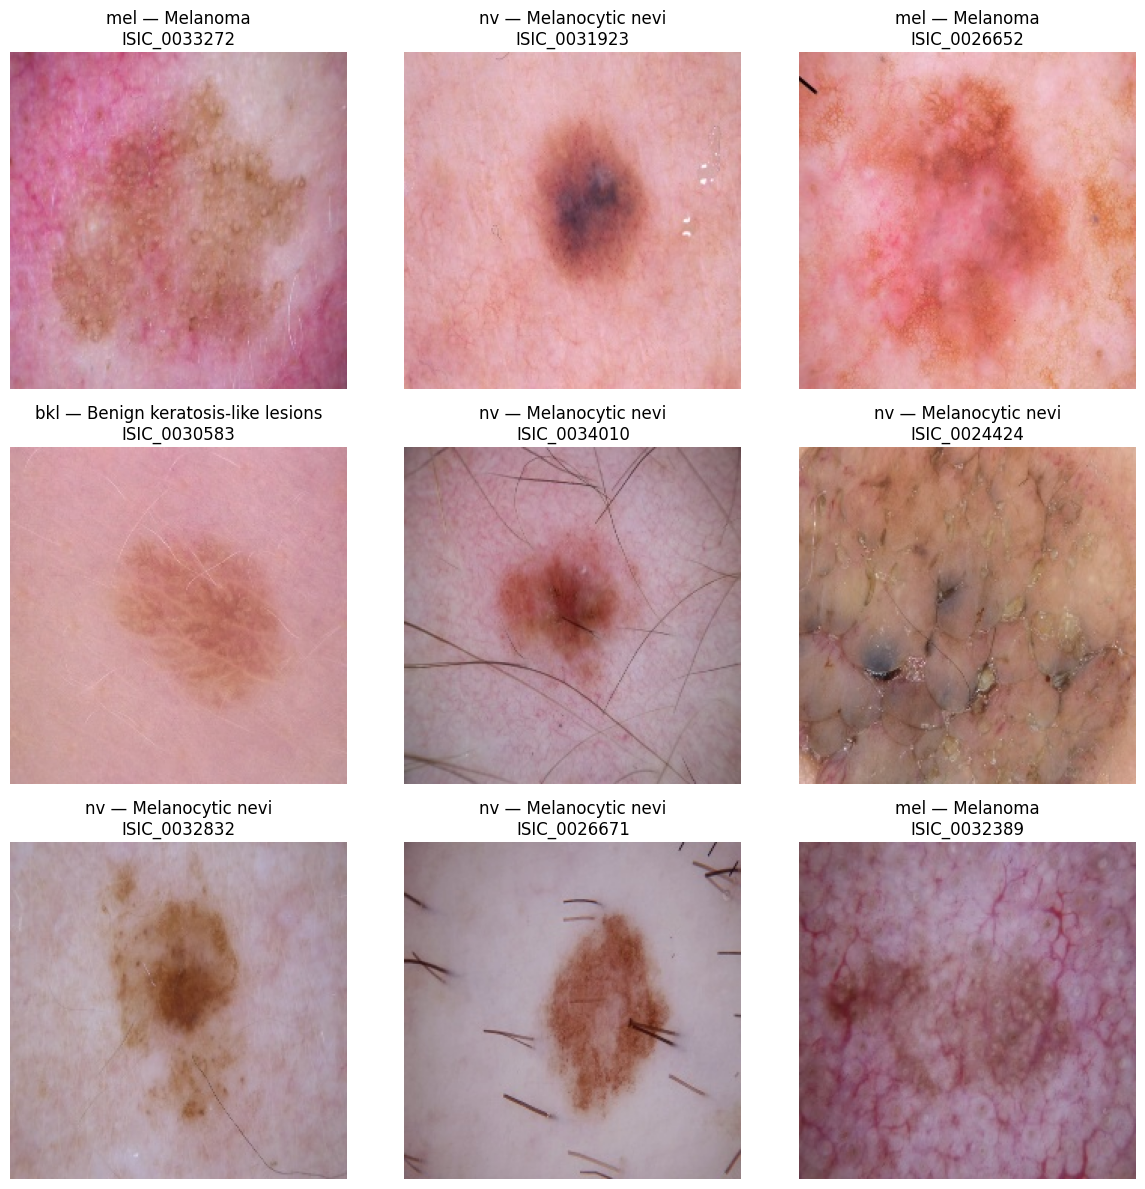

In [9]:
import matplotlib.pyplot as plt
from PIL import Image

sample_df = df[df["image_path"].notna()].sample(
    n=min(9, len(df)),
    random_state=42
)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for ax, (_, row) in zip(axes, sample_df.iterrows()):
    image = Image.open(row["image_path"]).convert("RGB")

    ax.imshow(image)
    ax.set_title(
        f"{row['dx']} — {row['label_name']}\n"
        f"{row['image_id']}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

In [10]:
from collections import Counter

sizes = []

for path in df["image_path"].dropna().head(1000):
    try:
        with Image.open(path) as img:
            sizes.append(img.size)
    except Exception as e:
        print("Could not read:", path, e)

size_counts = Counter(sizes)

print("Unique image sizes in first 1000 images:")
for size, count in size_counts.most_common(20):
    print(f"{size}: {count}")

print("\nMost common size:", size_counts.most_common(1)[0])

Unique image sizes in first 1000 images:
(224, 224): 1000

Most common size: ((224, 224), 1000)


In [11]:
print("Unique image IDs:", df["image_id"].nunique())
print("Total records:", len(df))

print("\nUnique lesion IDs:", df["lesion_id"].nunique())

duplicate_lesions = df["lesion_id"].value_counts()

print("\nLesions with multiple images:")
display(
    duplicate_lesions[duplicate_lesions > 1]
    .head(20)
    .rename_axis("lesion_id")
    .reset_index(name="number_of_images")
)

Unique image IDs: 10015
Total records: 10015

Unique lesion IDs: 7470

Lesions with multiple images:


,lesion_id,number_of_images
0,HAM_0003789,6
1,HAM_0005263,6
2,HAM_0000835,6
3,HAM_0001863,6
4,HAM_0000893,5
5,HAM_0007427,5
6,HAM_0007343,5
7,HAM_0002364,5
8,HAM_0007367,5
9,HAM_0000889,4


In [12]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

SEED = 42

# Work only with records that have valid image paths
df_valid = df[df["image_path"].notna()].copy()

print("Total images:", len(df_valid))
print("Unique lesions:", df_valid["lesion_id"].nunique())

# ---------------------------------------------------------
# Create one row per lesion
# Each lesion has a single diagnosis in HAM10000
# ---------------------------------------------------------

lesion_df = (
    df_valid[["lesion_id", "dx"]]
    .drop_duplicates(subset=["lesion_id"])
    .reset_index(drop=True)
)

print("\nLesion-level class distribution:")
display(
    lesion_df["dx"]
    .value_counts()
    .sort_index()
    .rename_axis("class")
    .reset_index(name="lesion_count")
)

# ---------------------------------------------------------
# 80% TRAIN / 20% TEMP
# ---------------------------------------------------------

train_lesions, temp_lesions = train_test_split(
    lesion_df,
    test_size=0.20,
    stratify=lesion_df["dx"],
    random_state=SEED
)

# ---------------------------------------------------------
# 10% VALIDATION / 10% TEST
# ---------------------------------------------------------

val_lesions, test_lesions = train_test_split(
    temp_lesions,
    test_size=0.50,
    stratify=temp_lesions["dx"],
    random_state=SEED
)

print("\nLesion-level split:")
print(f"Train lesions:      {len(train_lesions)}")
print(f"Validation lesions: {len(val_lesions)}")
print(f"Test lesions:       {len(test_lesions)}")

# ---------------------------------------------------------
# Map lesions back to ALL their images
# ---------------------------------------------------------

train_df = df_valid[
    df_valid["lesion_id"].isin(train_lesions["lesion_id"])
].copy()

val_df = df_valid[
    df_valid["lesion_id"].isin(val_lesions["lesion_id"])
].copy()

test_df = df_valid[
    df_valid["lesion_id"].isin(test_lesions["lesion_id"])
].copy()

print("\nImage-level split:")
print(f"Train images:      {len(train_df)}")
print(f"Validation images: {len(val_df)}")
print(f"Test images:       {len(test_df)}")
print(f"Total images:      {len(train_df) + len(val_df) + len(test_df)}")

Total images: 10015
Unique lesions: 7470

Lesion-level class distribution:


,class,lesion_count
0,akiec,228
1,bcc,327
2,bkl,727
3,df,73
4,mel,614
5,nv,5403
6,vasc,98



Lesion-level split:
Train lesions:      5976
Validation lesions: 747
Test lesions:       747

Image-level split:
Train images:      8020
Validation images: 1005
Test images:       990
Total images:      10015


In [13]:
# Image-level overlap
train_images = set(train_df["image_id"])
val_images = set(val_df["image_id"])
test_images = set(test_df["image_id"])

# Lesion-level overlap
train_lesions_set = set(train_df["lesion_id"])
val_lesions_set = set(val_df["lesion_id"])
test_lesions_set = set(test_df["lesion_id"])

print("========== IMAGE OVERLAP ==========")
print("Train ∩ Validation:", len(train_images & val_images))
print("Train ∩ Test:", len(train_images & test_images))
print("Validation ∩ Test:", len(val_images & test_images))

print("\n========== LESION OVERLAP ==========")
print("Train ∩ Validation:", len(train_lesions_set & val_lesions_set))
print("Train ∩ Test:", len(train_lesions_set & test_lesions_set))
print("Validation ∩ Test:", len(val_lesions_set & test_lesions_set))

assert len(train_images & val_images) == 0
assert len(train_images & test_images) == 0
assert len(val_images & test_images) == 0

assert len(train_lesions_set & val_lesions_set) == 0
assert len(train_lesions_set & test_lesions_set) == 0
assert len(val_lesions_set & test_lesions_set) == 0

print("\n✓ PASS: No image-level leakage.")
print("✓ PASS: No lesion-level leakage.")

========== IMAGE OVERLAP ==========
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0

========== LESION OVERLAP ==========
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0

✓ PASS: No image-level leakage.
✓ PASS: No lesion-level leakage.


In [14]:
def show_distribution(data, name):
    dist = (
        data["dx"]
        .value_counts()
        .sort_index()
        .rename_axis("class")
        .reset_index(name="count")
    )

    dist["percentage"] = (
        dist["count"] / len(data) * 100
    ).round(2)

    dist["class_name"] = dist["class"].map(label_names)

    print(f"\n{'=' * 60}")
    print(name)
    print(f"{'=' * 60}")

    display(
        dist[
            ["class", "class_name", "count", "percentage"]
        ]
    )


show_distribution(train_df, "TRAIN")
show_distribution(val_df, "VALIDATION")
show_distribution(test_df, "TEST")


TRAIN


,class,class_name,count,percentage
0,akiec,Actinic keratoses,265,3.30
1,bcc,Basal cell carcinoma,414,5.16
2,bkl,Benign keratosis-like lesions,881,10.99
3,df,Dermatofibroma,87,1.08
4,mel,Melanoma,895,11.16
5,nv,Melanocytic nevi,5368,66.93
6,vasc,Vascular lesions,110,1.37



VALIDATION


,class,class_name,count,percentage
0,akiec,Actinic keratoses,34,3.38
1,bcc,Basal cell carcinoma,50,4.98
2,bkl,Benign keratosis-like lesions,108,10.75
3,df,Dermatofibroma,14,1.39
4,mel,Melanoma,116,11.54
5,nv,Melanocytic nevi,668,66.47
6,vasc,Vascular lesions,15,1.49



TEST


,class,class_name,count,percentage
0,akiec,Actinic keratoses,28,2.83
1,bcc,Basal cell carcinoma,50,5.05
2,bkl,Benign keratosis-like lesions,110,11.11
3,df,Dermatofibroma,14,1.41
4,mel,Melanoma,102,10.30
5,nv,Melanocytic nevi,669,67.58
6,vasc,Vascular lesions,17,1.72


In [15]:
split_summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Images": [
        len(train_df),
        len(val_df),
        len(test_df)
    ],
    "Lesions": [
        train_df["lesion_id"].nunique(),
        val_df["lesion_id"].nunique(),
        test_df["lesion_id"].nunique()
    ]
})

split_summary["Image %"] = (
    split_summary["Images"] /
    split_summary["Images"].sum() * 100
).round(2)

split_summary["Lesion %"] = (
    split_summary["Lesions"] /
    split_summary["Lesions"].sum() * 100
).round(2)

display(split_summary)

,Split,Images,Lesions,Image %,Lesion %
0,Train,8020,5976,80.08,80.0
1,Validation,1005,747,10.03,10.0
2,Test,990,747,9.89,10.0


In [16]:
# Create mapping of lesion -> split
lesion_split = {}

for lesion_id in train_df["lesion_id"].unique():
    lesion_split[lesion_id] = "train"

for lesion_id in val_df["lesion_id"].unique():
    if lesion_id in lesion_split:
        raise ValueError(f"Lesion appears in multiple splits: {lesion_id}")
    lesion_split[lesion_id] = "validation"

for lesion_id in test_df["lesion_id"].unique():
    if lesion_id in lesion_split:
        raise ValueError(f"Lesion appears in multiple splits: {lesion_id}")
    lesion_split[lesion_id] = "test"

print("Total unique lesions assigned:", len(lesion_split))
print("Original unique lesions:", df_valid["lesion_id"].nunique())

assert len(lesion_split) == df_valid["lesion_id"].nunique()

print("\n✓ Every lesion is assigned to exactly one split.")

Total unique lesions assigned: 7470
Original unique lesions: 7470

✓ Every lesion is assigned to exactly one split.


In [17]:
from pathlib import Path

SPLIT_DIR = Path("/content/ham10000_splits")
SPLIT_DIR.mkdir(exist_ok=True)

train_path = SPLIT_DIR / "train.csv"
val_path = SPLIT_DIR / "validation.csv"
test_path = SPLIT_DIR / "test.csv"

train_df.to_csv(train_path, index=False)
val_df.to_csv(val_path, index=False)
test_df.to_csv(test_path, index=False)

print("Saved corrected leakage-free splits:")

print(train_path)
print(val_path)
print(test_path)

Saved corrected leakage-free splits:
/content/ham10000_splits/train.csv
/content/ham10000_splits/validation.csv
/content/ham10000_splits/test.csv


In [18]:
# Reload saved files
train_check = pd.read_csv(train_path)
val_check = pd.read_csv(val_path)
test_check = pd.read_csv(test_path)

# Basic counts
assert len(train_check) + len(val_check) + len(test_check) == len(df_valid)

# Image uniqueness
all_images = (
    list(train_check["image_id"]) +
    list(val_check["image_id"]) +
    list(test_check["image_id"])
)

assert len(all_images) == len(set(all_images))

# Lesion uniqueness
all_lesions = (
    list(train_check["lesion_id"]) +
    list(val_check["lesion_id"]) +
    list(test_check["lesion_id"])
)

# A lesion may occur multiple times because it has multiple images,
# so check unique lesion sets instead.
assert set(train_check["lesion_id"]).isdisjoint(
    set(val_check["lesion_id"])
)

assert set(train_check["lesion_id"]).isdisjoint(
    set(test_check["lesion_id"])
)

assert set(val_check["lesion_id"]).isdisjoint(
    set(test_check["lesion_id"])
)

print("=" * 70)
print("FINAL DATASET SPLIT AUDIT")
print("=" * 70)

print(f"Total images:          {len(df_valid)}")
print(f"Total unique lesions:  {df_valid['lesion_id'].nunique()}")
print()
print(f"Train images:          {len(train_check)}")
print(f"Validation images:     {len(val_check)}")
print(f"Test images:           {len(test_check)}")
print()
print(f"Train lesions:         {train_check['lesion_id'].nunique()}")
print(f"Validation lesions:    {val_check['lesion_id'].nunique()}")
print(f"Test lesions:          {test_check['lesion_id'].nunique()}")

print("\n✓ No image leakage")
print("✓ No lesion leakage")
print("✓ Stratification applied at lesion level")
print("✓ Splits saved and verified")

FINAL DATASET SPLIT AUDIT
Total images:          10015
Total unique lesions:  7470

Train images:          8020
Validation images:     1005
Test images:           990

Train lesions:         5976
Validation lesions:    747
Test lesions:          747

✓ No image leakage
✓ No lesion leakage
✓ Stratification applied at lesion level
✓ Splits saved and verified


## Phase 2: Transfer Learning — Model Comparison (Table 1)

Train 8 CNN backbones (AlexNet, VGG16, VGG19, ResNet18/50/101, DenseNet121, EfficientNet-B0) on the leakage-free splits, using ImageNet weights + fine-tuning, following the paper's preprocessing (resize, normalize, flip/shift/zoom augmentation) and handling class imbalance via a weighted loss.

In [19]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import numpy as np
import random
import time

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

IMG_SIZE = 224
BATCH_SIZE = 64          # T4 (16GB) handles this at 224x224 for most backbones; drop to 32 for VGG16/19, ResNet101 if you OOM
NUM_WORKERS = 2          # bump from 2 -- dataloader/CPU decode was the likely bottleneck, not the GPU
NUM_EPOCHS = 15
LR = 5e-5
PATIENCE = 6             # early stopping on val macro-F1 (raised so the LR scheduler gets a chance to act first)

CLASSES = sorted(label_names.keys())          # e.g. ['akiec','bcc','bkl','df','mel','nv','vasc']
NUM_CLASSES = len(CLASSES)
class_to_idx = {c: i for i, c in enumerate(CLASSES)}
idx_to_class = {i: c for c, i in class_to_idx.items()}
print("Classes:", class_to_idx)


Device: cuda
Classes: {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


In [20]:
class HAM10000Dataset(Dataset):
    def __init__(self, df, class_to_idx, transform=None):
        self.paths = df["image_path"].values
        self.labels = df["dx"].map(class_to_idx).values
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        image = Image.open(self.paths[idx]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]


IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomAffine(degrees=0, translate=(0.2, 0.2), scale=(0.8, 1.2), shear=10),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_dataset = HAM10000Dataset(train_df, class_to_idx, train_transform)
val_dataset = HAM10000Dataset(val_df, class_to_idx, eval_transform)
test_dataset = HAM10000Dataset(test_df, class_to_idx, eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")


Train: 8020 | Val: 1005 | Test: 990


In [21]:
from sklearn.utils.class_weight import compute_class_weight

train_labels_encoded = train_df["dx"].map(class_to_idx).values
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_labels_encoded,
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
print("Class weights:", dict(zip(CLASSES, class_weights.round(3))))


Class weights: {'akiec': np.float64(4.323), 'bcc': np.float64(2.767), 'bkl': np.float64(1.3), 'df': np.float64(13.169), 'mel': np.float64(1.28), 'nv': np.float64(0.213), 'vasc': np.float64(10.416)}


In [22]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score
from sklearn.preprocessing import label_binarize

def compute_metrics(y_true, y_pred, y_proba, num_classes=NUM_CLASSES):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    try:
        y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))
        auc = roc_auc_score(y_true_bin, y_proba, average="macro", multi_class="ovr")
    except ValueError:
        auc = float("nan")
    return {
        "Accuracy (%)": round(acc * 100, 2),
        "Precision (%)": round(precision * 100, 2),
        "Recall (%)": round(recall * 100, 2),
        "F1-Score (%)": round(f1 * 100, 2),
        "AUC (%)": round(float(auc) * 100, 2),
    }


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_labels, all_preds, all_proba = [], [], []
    for images, labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        with torch.autocast(device_type=DEVICE.type, enabled=(DEVICE.type == "cuda")):
            logits = model(images)
        proba = torch.softmax(logits.float(), dim=1).cpu().numpy()
        preds = proba.argmax(axis=1)
        all_labels.extend(labels.numpy())
        all_preds.extend(preds)
        all_proba.extend(proba)
    return compute_metrics(np.array(all_labels), np.array(all_preds), np.array(all_proba))


In [23]:
def build_model(name, num_classes=NUM_CLASSES, pretrained=True):
    """Returns (model, feature_layer_name) where feature_layer_name is the
    attribute path of the final classification layer (used later for
    swapping it out to extract deep features)."""
    weights_arg = "DEFAULT" if pretrained else None

    if name == "AlexNet":
        model = models.alexnet(weights=weights_arg)
        in_f = model.classifier[6].in_features
        model.classifier[6] = nn.Linear(in_f, num_classes)
        head = ("classifier", 6)

    elif name == "VGG16":
        model = models.vgg16(weights=weights_arg)
        in_f = model.classifier[6].in_features
        model.classifier[6] = nn.Linear(in_f, num_classes)
        head = ("classifier", 6)

    elif name == "VGG19":
        model = models.vgg19(weights=weights_arg)
        in_f = model.classifier[6].in_features
        model.classifier[6] = nn.Linear(in_f, num_classes)
        head = ("classifier", 6)

    elif name == "ResNet18":
        model = models.resnet18(weights=weights_arg)
        in_f = model.fc.in_features
        model.fc = nn.Linear(in_f, num_classes)
        head = ("fc", None)

    elif name == "ResNet50":
        model = models.resnet50(weights=weights_arg)
        in_f = model.fc.in_features
        model.fc = nn.Linear(in_f, num_classes)
        head = ("fc", None)

    elif name == "ResNet101":
        model = models.resnet101(weights=weights_arg)
        in_f = model.fc.in_features
        model.fc = nn.Linear(in_f, num_classes)
        head = ("fc", None)

    elif name == "DenseNet121":
        model = models.densenet121(weights=weights_arg)
        in_f = model.classifier.in_features
        model.classifier = nn.Linear(in_f, num_classes)
        head = ("classifier", None)

    elif name == "EfficientNet-B0":
        model = models.efficientnet_b0(weights=weights_arg)
        in_f = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_f, num_classes)
        head = ("classifier", 1)

    else:
        raise ValueError(f"Unknown model: {name}")

    return model.to(DEVICE), head


MODEL_NAMES = [
    "AlexNet", "VGG16", "VGG19",
    "ResNet18", "ResNet50", "ResNet101",
    "DenseNet121", "EfficientNet-B0",
]


In [24]:
def train_model(model, train_loader, val_loader, num_epochs=NUM_EPOCHS, patience=PATIENCE, lr=LR):
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)
    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))

    best_f1 = -1
    best_state = None
    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        t0 = time.perf_counter()
        for images, labels in train_loader:
            images, labels = images.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
            optimizer.zero_grad()
            with torch.autocast(device_type=DEVICE.type, enabled=(DEVICE.type == "cuda")):
                outputs = model(images)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item() * images.size(0)

        train_loss = running_loss / len(train_loader.dataset)
        val_metrics = evaluate(model, val_loader)
        scheduler.step(val_metrics["F1-Score (%)"])
        epoch_time = time.perf_counter() - t0

        print(f"  Epoch {epoch+1}/{num_epochs} | loss {train_loss:.4f} | "
              f"val acc {val_metrics['Accuracy (%)']:.2f} | val F1 {val_metrics['F1-Score (%)']:.2f} | "
              f"lr {optimizer.param_groups[0]['lr']:.2e} | {epoch_time:.1f}s")

        if val_metrics["F1-Score (%)"] > best_f1:
            best_f1 = val_metrics["F1-Score (%)"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print("  Early stopping.")
                break

    model.load_state_dict(best_state)
    return model


In [25]:
trained_models = {}
model_heads = {}
table1_results = []

for name in MODEL_NAMES:
    print(f"\n===== Training {name} =====")
    model, head = build_model(name)
    model = train_model(model, train_loader, val_loader)
    test_metrics = evaluate(model, test_loader)
    print(f"  TEST -> {test_metrics}")

    trained_models[name] = model
    model_heads[name] = head
    table1_results.append({"Model": name, **test_metrics})

    # free GPU memory between big models if needed
    torch.cuda.empty_cache()



===== Training AlexNet =====
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 183MB/s]
/tmp/ipykernel_10375/4282843526.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))


  Epoch 1/15 | loss 1.4345 | val acc 50.95 | val F1 38.59 | lr 5.00e-05 | 21.3s
  Epoch 2/15 | loss 1.0312 | val acc 69.55 | val F1 58.15 | lr 5.00e-05 | 18.7s
  Epoch 3/15 | loss 0.9113 | val acc 61.09 | val F1 54.76 | lr 5.00e-05 | 21.2s
  Epoch 4/15 | loss 0.8451 | val acc 61.09 | val F1 50.63 | lr 5.00e-05 | 18.6s
  Epoch 5/15 | loss 0.7733 | val acc 66.77 | val F1 56.08 | lr 5.00e-05 | 19.3s
  Epoch 6/15 | loss 0.7096 | val acc 68.06 | val F1 55.45 | lr 2.50e-05 | 18.4s
  Epoch 7/15 | loss 0.5969 | val acc 68.86 | val F1 61.78 | lr 2.50e-05 | 19.2s
  Epoch 8/15 | loss 0.5707 | val acc 66.17 | val F1 57.86 | lr 2.50e-05 | 18.3s
  Epoch 9/15 | loss 0.5639 | val acc 64.08 | val F1 57.60 | lr 2.50e-05 | 18.2s
  Epoch 10/15 | loss 0.5135 | val acc 68.66 | val F1 60.68 | lr 2.50e-05 | 19.3s
  Epoch 11/15 | loss 0.4835 | val acc 65.57 | val F1 58.46 | lr 1.25e-05 | 18.3s
  Epoch 12/15 | loss 0.4534 | val acc 68.76 | val F1 61.71 | lr 1.25e-05 | 19.3s
  Epoch 13/15 | loss 0.4392 | val acc

100%|██████████| 528M/528M [00:05<00:00, 100MB/s]
/tmp/ipykernel_10375/4282843526.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))


  Epoch 1/15 | loss 1.4505 | val acc 59.80 | val F1 47.55 | lr 5.00e-05 | 65.1s
  Epoch 2/15 | loss 1.0903 | val acc 62.69 | val F1 50.07 | lr 5.00e-05 | 64.6s
  Epoch 3/15 | loss 0.9498 | val acc 53.93 | val F1 42.86 | lr 5.00e-05 | 64.4s
  Epoch 4/15 | loss 0.7866 | val acc 62.59 | val F1 53.88 | lr 5.00e-05 | 64.4s
  Epoch 5/15 | loss 0.7216 | val acc 67.76 | val F1 56.02 | lr 5.00e-05 | 64.3s
  Epoch 6/15 | loss 0.6494 | val acc 78.21 | val F1 61.97 | lr 5.00e-05 | 64.3s
  Epoch 7/15 | loss 0.5623 | val acc 71.94 | val F1 60.68 | lr 5.00e-05 | 64.2s
  Epoch 8/15 | loss 0.5068 | val acc 69.75 | val F1 56.94 | lr 5.00e-05 | 64.4s
  Epoch 9/15 | loss 0.5294 | val acc 68.46 | val F1 62.39 | lr 5.00e-05 | 64.1s
  Epoch 10/15 | loss 0.4339 | val acc 73.43 | val F1 58.36 | lr 5.00e-05 | 64.4s
  Epoch 11/15 | loss 0.4078 | val acc 74.53 | val F1 61.34 | lr 5.00e-05 | 64.1s
  Epoch 12/15 | loss 0.3694 | val acc 71.74 | val F1 59.83 | lr 5.00e-05 | 64.0s
  Epoch 13/15 | loss 0.3313 | val acc

...

  Epoch 1/15 | loss 1.5824 | val acc 64.68 | val F1 48.73 | lr 5.00e-05 | 53.1s
  Epoch 2/15 | loss 0.7839 | val acc 73.63 | val F1 62.16 | lr 5.00e-05 | 52.6s
  Epoch 3/15 | loss 0.5681 | val acc 72.74 | val F1 60.27 | lr 5.00e-05 | 52.6s
  Epoch 4/15 | loss 0.4215 | val acc 76.12 | val F1 64.37 | lr 5.00e-05 | 52.6s
  Epoch 5/15 | loss 0.3274 | val acc 78.41 | val F1 67.61 | lr 5.00e-05 | 52.6s
  Epoch 6/15 | loss 0.2604 | val acc 77.61 | val F1 67.44 | lr 5.00e-05 | 52.6s
  Epoch 7/15 | loss 0.2220 | val acc 79.40 | val F1 67.75 | lr 5.00e-05 | 52.5s
  Epoch 8/15 | loss 0.1784 | val acc 80.20 | val F1 69.50 | lr 5.00e-05 | 52.7s
  Epoch 9/15 | loss 0.1384 | val acc 79.70 | val F1 68.49 | lr 5.00e-05 | 52.7s
  Epoch 10/15 | loss 0.1289 | val acc 80.30 | val F1 64.12 | lr 5.00e-05 | 52.6s
  Epoch 11/15 | loss 0.1053 | val acc 80.40 | val F1 67.49 | lr 5.00e-05 | 52.5s
  Epoch 12/15 | loss 0.0996 | val acc 81.39 | val F1 67.71 | lr 2.50e-05 | 52.7s
  Epoch 13/15 | loss 0.0654 | val acc

100%|██████████| 30.8M/30.8M [00:00<00:00, 108MB/s] 
/tmp/ipykernel_10375/4282843526.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))


  Epoch 1/15 | loss 1.3513 | val acc 60.10 | val F1 47.32 | lr 5.00e-05 | 40.3s
  Epoch 2/15 | loss 0.7916 | val acc 69.55 | val F1 56.92 | lr 5.00e-05 | 39.3s
  Epoch 3/15 | loss 0.6099 | val acc 70.35 | val F1 58.29 | lr 5.00e-05 | 39.5s
  Epoch 4/15 | loss 0.5057 | val acc 70.95 | val F1 62.14 | lr 5.00e-05 | 39.5s
  Epoch 5/15 | loss 0.4360 | val acc 76.02 | val F1 66.62 | lr 5.00e-05 | 39.4s
  Epoch 6/15 | loss 0.3726 | val acc 73.33 | val F1 62.62 | lr 5.00e-05 | 39.4s
  Epoch 7/15 | loss 0.3394 | val acc 75.32 | val F1 63.09 | lr 5.00e-05 | 39.6s
  Epoch 8/15 | loss 0.2892 | val acc 77.31 | val F1 67.75 | lr 5.00e-05 | 39.7s
  Epoch 9/15 | loss 0.2518 | val acc 78.61 | val F1 70.40 | lr 5.00e-05 | 39.5s
  Epoch 10/15 | loss 0.2374 | val acc 79.90 | val F1 69.94 | lr 5.00e-05 | 39.5s
  Epoch 11/15 | loss 0.2193 | val acc 82.19 | val F1 72.57 | lr 5.00e-05 | 39.4s
  Epoch 12/15 | loss 0.1828 | val acc 80.20 | val F1 67.40 | lr 5.00e-05 | 39.6s
  Epoch 13/15 | loss 0.1719 | val acc

100%|██████████| 20.5M/20.5M [00:00<00:00, 154MB/s]
/tmp/ipykernel_10375/4282843526.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))


  Epoch 1/15 | loss 1.7084 | val acc 48.66 | val F1 37.31 | lr 5.00e-05 | 48.5s
  Epoch 2/15 | loss 1.1674 | val acc 60.50 | val F1 47.22 | lr 5.00e-05 | 25.3s
  Epoch 3/15 | loss 0.8694 | val acc 64.18 | val F1 52.30 | lr 5.00e-05 | 25.4s
  Epoch 4/15 | loss 0.7289 | val acc 69.85 | val F1 57.52 | lr 5.00e-05 | 25.3s
  Epoch 5/15 | loss 0.6287 | val acc 70.95 | val F1 59.18 | lr 5.00e-05 | 25.3s
  Epoch 6/15 | loss 0.5645 | val acc 72.64 | val F1 60.81 | lr 5.00e-05 | 25.3s
  Epoch 7/15 | loss 0.4829 | val acc 73.33 | val F1 61.99 | lr 5.00e-05 | 25.2s
  Epoch 8/15 | loss 0.4450 | val acc 72.74 | val F1 62.54 | lr 5.00e-05 | 25.0s
  Epoch 9/15 | loss 0.4133 | val acc 74.63 | val F1 64.99 | lr 5.00e-05 | 25.3s
  Epoch 10/15 | loss 0.3796 | val acc 75.02 | val F1 64.16 | lr 5.00e-05 | 25.3s
  Epoch 11/15 | loss 0.3433 | val acc 76.22 | val F1 65.35 | lr 5.00e-05 | 24.8s
  Epoch 12/15 | loss 0.3275 | val acc 76.72 | val F1 65.24 | lr 5.00e-05 | 25.2s
  Epoch 13/15 | loss 0.3048 | val acc

In [26]:
import pandas as pd

table1_df = pd.DataFrame(table1_results).set_index("Model")
display(table1_df)

table1_df.to_csv("/content/table1_transfer_learning_comparison.csv")

BEST_MODEL_NAME = table1_df["F1-Score (%)"].astype(float).idxmax()
print("\nBest backbone (by macro F1):", BEST_MODEL_NAME)


,Accuracy (%),Precision (%),Recall (%),F1-Score (%),AUC (%)
Model,,,,,
AlexNet,70.40,50.11,59.46,53.36,93.10
VGG16,76.77,62.14,63.19,60.98,94.84
VGG19,76.97,59.34,65.49,61.31,94.39
ResNet18,76.97,62.01,66.50,62.53,93.95
ResNet50,80.20,61.34,66.49,63.52,94.01
ResNet101,80.91,65.09,73.60,68.59,92.50
DenseNet121,82.22,67.54,70.15,68.53,94.98
EfficientNet-B0,78.99,62.73,73.18,65.89,93.05



Best backbone (by macro F1): ResNet101


## Phase 3: Deep Feature Extraction + Classical Classifiers (Table 2)

Take the best backbone from Table 1, strip its classification head, extract deep features for train/val/test, then fit several classical ML classifiers on top of those features.

In [27]:
import copy

def get_feature_extractor(model, head):
    """Returns a copy of `model` with its final classification layer
    replaced by nn.Identity(), so forward() returns the deep feature vector."""
    feat_model = copy.deepcopy(model)
    attr, idx = head
    module = getattr(feat_model, attr)
    if idx is None:
        setattr(feat_model, attr, nn.Identity())
    else:
        module[idx] = nn.Identity()
    feat_model.eval().to(DEVICE)
    return feat_model


@torch.no_grad()
def extract_features(feat_model, loader):
    feats, labels_out = [], []
    for images, labels in loader:
        images = images.to(DEVICE)
        f = feat_model(images)
        f = torch.flatten(f, 1)
        feats.append(f.cpu().numpy())
        labels_out.append(labels.numpy())
    return np.concatenate(feats), np.concatenate(labels_out)


best_model = trained_models[BEST_MODEL_NAME]
best_head = model_heads[BEST_MODEL_NAME]
feature_extractor = get_feature_extractor(best_model, best_head)

# use non-augmented loaders for consistent feature extraction on the train set too
train_loader_eval = DataLoader(HAM10000Dataset(train_df, class_to_idx, eval_transform),
                                batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

X_train, y_train = extract_features(feature_extractor, train_loader_eval)
X_val, y_val = extract_features(feature_extractor, val_loader)
X_test, y_test = extract_features(feature_extractor, test_loader)

print("Feature shapes:", X_train.shape, X_val.shape, X_test.shape)

np.savez("/content/deep_features.npz",
         X_train=X_train, y_train=y_train,
         X_val=X_val, y_val=y_val,
         X_test=X_test, y_test=y_test)


Feature shapes: (8020, 2048) (1005, 2048) (990, 2048)


In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

# combine train+val for fitting classical classifiers, keep test untouched
X_trainval_s = np.concatenate([X_train_s, X_val_s])
y_trainval = np.concatenate([y_train, y_val])


In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier   # pip install xgboost if not already available

classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=SEED, n_jobs=-1),
    "K-Nearest Neighbors (KNN)": KNeighborsClassifier(n_neighbors=7),
    "Linear SVM": SVC(kernel="linear", probability=True, class_weight="balanced", random_state=SEED),
    "RBF-SVM": SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=SEED),
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        objective="multi:softprob", num_class=NUM_CLASSES,
        eval_metric="mlogloss", random_state=SEED, n_jobs=-1,
    ),
}

table2_results = []
fitted_classifiers = {}

for clf_name, clf in classifiers.items():
    print(f"\n===== {clf_name} =====")
    clf.fit(X_trainval_s, y_trainval)
    y_pred = clf.predict(X_test_s)
    y_proba = clf.predict_proba(X_test_s)
    metrics = compute_metrics(y_test, y_pred, y_proba)
    print(metrics)
    fitted_classifiers[clf_name] = clf
    table2_results.append({
        "Feature Extractor": f"Deep Features ({BEST_MODEL_NAME})",
        "Classifier": clf_name,
        **metrics,
    })



===== Logistic Regression =====
{'Accuracy (%)': 81.72, 'Precision (%)': 68.14, 'Recall (%)': 67.68, 'F1-Score (%)': 67.64, 'AUC (%)': 90.41}

===== Decision Tree =====
{'Accuracy (%)': 76.16, 'Precision (%)': 62.09, 'Recall (%)': 60.15, 'F1-Score (%)': 60.52, 'AUC (%)': 76.85}

===== Random Forest =====
{'Accuracy (%)': 82.12, 'Precision (%)': 72.65, 'Recall (%)': 65.15, 'F1-Score (%)': 68.34, 'AUC (%)': 94.94}

===== K-Nearest Neighbors (KNN) =====
{'Accuracy (%)': 82.22, 'Precision (%)': 69.34, 'Recall (%)': 65.8, 'F1-Score (%)': 67.31, 'AUC (%)': 87.31}

===== Linear SVM =====
{'Accuracy (%)': 82.32, 'Precision (%)': 67.96, 'Recall (%)': 68.06, 'F1-Score (%)': 67.7, 'AUC (%)': 94.48}

===== RBF-SVM =====
{'Accuracy (%)': 81.31, 'Precision (%)': 65.88, 'Recall (%)': 68.75, 'F1-Score (%)': 66.95, 'AUC (%)': 95.17}

===== XGBoost =====
{'Accuracy (%)': 82.93, 'Precision (%)': 71.08, 'Recall (%)': 67.59, 'F1-Score (%)': 69.1, 'AUC (%)': 95.33}


In [30]:
table2_df = pd.DataFrame(table2_results).set_index(["Feature Extractor", "Classifier"])
display(table2_df)
table2_df.to_csv("/content/table2_classifier_comparison.csv")

BEST_CLASSIFIER_NAME = table2_df["F1-Score (%)"].astype(float).idxmax()[1]
print("\nBest classifier on deep features:", BEST_CLASSIFIER_NAME)


Accuracy (%)  \
Feature Extractor         Classifier                                
Deep Features (ResNet101) Logistic Regression               81.72   
                          Decision Tree                     76.16   
                          Random Forest                     82.12   
                          K-Nearest Neighbors (KNN)         82.22   
                          Linear SVM                        82.32   
                          RBF-SVM                           81.31   
                          XGBoost                           82.93   

                                                     Precision (%)  \
Feature Extractor         Classifier                                 
Deep Features (ResNet101) Logistic Regression                68.14   
                          Decision Tree                      62.09   
                          Random Forest                      72.65   
                          K-Nearest Neighbors (KNN)          69.34   
                          Linear SVM                         67.96   
                          RBF-SVM                            65.88   
                          XGBoost                            71.08   

                                                     Recall (%)  F1-Score (%)  \
Feature Extractor         Classifier                                            
Deep Features (ResNet101) Logistic Regression             67.68         67.64   
                          Decision Tree                   60.15         60.52   
                          Random Forest                   65.15         68.34   
                          K-Nearest Neighbors (KNN)       65.80         67.31   
                          Linear SVM                      68.06         67.70   
                          RBF-SVM                         68.75         66.95   
                          XGBoost                         67.59         69.10   

                                                     AUC (%)  
Feature Extractor         Classifier                          
Deep Features (ResNet101) Logistic Regression          90.41  
                          Decision Tree                76.85  
                          Random Forest                94.94  
                          K-Nearest Neighbors (KNN)    87.31  
                          Linear SVM                   94.48  
                          RBF-SVM                      95.17  
                          XGBoost                      95.33


Best classifier on deep features: XGBoost


## Phase 4: Computational Efficiency Comparison (Table 3)

Parameter counts, on-disk model size, FLOPs, and single-image inference latency for each of the 8 backbones.

In [31]:
!pip install -q thop

import io
from thop import profile

def count_parameters(model):
    return sum(p.numel() for p in model.parameters()) / 1e6  # millions

def model_size_mb(model):
    buffer = io.BytesIO()
    torch.save(model.state_dict(), buffer)
    return len(buffer.getvalue()) / 1e6

def compute_flops(model, img_size=IMG_SIZE):
    dummy = torch.randn(1, 3, img_size, img_size).to(DEVICE)
    flops, _ = profile(model, inputs=(dummy,), verbose=False)
    return flops / 1e9  # GFLOPs

@torch.no_grad()
def measure_inference_time(model, img_size=IMG_SIZE, n_runs=50, warmup=10):
    model.eval()
    dummy = torch.randn(1, 3, img_size, img_size).to(DEVICE)
    for _ in range(warmup):
        model(dummy)
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    start = time.perf_counter()
    for _ in range(n_runs):
        model(dummy)
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - start
    return (elapsed / n_runs) * 1000  # ms


In [32]:
table3_results = []

for name in MODEL_NAMES:
    model = trained_models[name]
    params_m = count_parameters(model)
    size_mb = model_size_mb(model)
    flops_g = compute_flops(model)
    infer_ms = measure_inference_time(model)
    acc = table1_df.loc[name, "Accuracy (%)"]

    table3_results.append({
        "Model": name,
        "Parameters (M)": round(params_m, 2),
        "Model Size (MB)": round(size_mb, 2),
        "FLOPs (G)": round(flops_g, 2),
        "Inference Time (ms)": round(infer_ms, 2),
        "Accuracy (%)": acc,
    })

table3_df = pd.DataFrame(table3_results).set_index("Model")
display(table3_df)
table3_df.to_csv("/content/table3_computational_efficiency.csv")


,Parameters (M),Model Size (MB),FLOPs (G),Inference Time (ms),Accuracy (%)
Model,,,,,
AlexNet,57.03,228.14,0.71,2.10,70.40
VGG16,134.29,537.17,15.47,9.27,76.77
VGG19,139.60,558.41,19.63,10.79,76.97
ResNet18,11.18,44.80,1.82,3.27,76.97
ResNet50,23.52,94.41,4.13,12.34,80.20
ResNet101,42.51,170.68,7.86,28.66,80.91
DenseNet121,6.96,28.45,2.90,36.95,82.22
EfficientNet-B0,4.02,16.36,0.41,20.82,78.99


## Summary

All three result tables are saved to `/content/` as CSVs:
- `table1_transfer_learning_comparison.csv`
- `table2_classifier_comparison.csv`
- `table3_computational_efficiency.csv`

Best backbone and best classifier-on-deep-features are picked automatically above by macro F1-score; swap that criterion for accuracy/AUC if you'd rather optimize for those.